# Generate plot for the paper

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
sns.set(rc={'text.usetex' : True})

## Load Online data

In [3]:
online = pd.read_csv(Path("results/farm/summary.csv"))

In [4]:
palette = {
    "baseline": "tab:gray",
    "ppo_10steps": "dimgray",
    "ppo_10steps_rs5": "gray",
    "q_network_10steps": "darkgray",
    "q_network_10steps_rs5": "lightgray",
    "gpt4omini": "tab:red",
    # "claude35haiku": "tab:blue",
    "gemini20flash": "tab:cyan",
    "gpt4o": "tab:orange",
    "claude37sonnet": "tab:green",
    "o3mini": "tab:blue",
}

In [5]:
baseline_names = {
    "baseline": "Rule-based",
    "ppo_10steps": "PPO",
    "ppo_10steps_rs5": "PPO + shaping",
    "q_network_10steps": "Q-Network",
    "q_network_10steps_rs5": "Q-Network + shaping",
}
llm_names = {
    "gpt4omini": "GPT-4o mini",
    # "claude35haiku": "Claude 3.5 Haiku",
    "gemini20flash": "Gemini 2.0 Flash",
    "gpt4o": "GPT-4o",
    "claude37sonnet": "Claude 3.7 Sonnet",
    "o3mini": "OpenAI o3-mini",
}
all_names = {**baseline_names, **llm_names}
online['LLM'] = online['llm'].map(all_names)
palette_baselines = {v: palette[k] for k, v in baseline_names.items()}
palette_LLM = {v: palette[k] for k, v in llm_names.items()}
online["params"] = online["params"].replace({
    "Rule-based Smart": "Rule-based",
    "Default": "Zero\nstrategy",
    "Hinted": "High-level\nstrategy",
    "Step-by-Step": "Low-level\nstrategy",
})

In [6]:
online

,llm,params,damage,LLM
0,baseline,Rule-based,31.0,Rule-based
1,baseline,Rule-based,31.0,Rule-based
2,baseline,Rule-based,27.0,Rule-based
3,baseline,Rule-based,32.0,Rule-based
4,baseline,Rule-based,24.0,Rule-based
...,...,...,...,...
107,o3mini,High-level\nstrategy,30.0,OpenAI o3-mini
108,o3mini,High-level\nstrategy,34.0,OpenAI o3-mini
109,o3mini,High-level\nstrategy,20.0,OpenAI o3-mini
110,o3mini,High-level\nstrategy,33.0,OpenAI o3-mini


## Load Offline data

In [7]:
offline = pd.read_csv(Path("logs/generated/no_battery/summary.csv"))

In [8]:
offline['LLM'] = offline['llm'].map({
    "4o": "GPT-4o",
    "o3": "OpenAI o3-mini",
})

In [9]:
offline

,llm,params,repeat,version,damage,LLM
0,4o,Default,2,1,291,GPT-4o
1,4o,Default,2,1,272,GPT-4o
2,4o,Default,2,1,293,GPT-4o
3,4o,Default,2,1,216,GPT-4o
4,4o,Default,2,1,252,GPT-4o
...,...,...,...,...,...,...
170,o3,Hinted,4,2,264,OpenAI o3-mini
171,o3,Hinted,4,2,206,OpenAI o3-mini
172,o3,Hinted,4,2,280,OpenAI o3-mini
173,o3,Hinted,4,2,245,OpenAI o3-mini


In [10]:
offline["params"] = offline["params"].replace({
    "Default": "Zero\nstrategy",
    "Hinted": "High-level\nstrategy",
    "Step-by-Step": "Low-level\nstrategy",
})

In [21]:
offline_v1 = offline[offline["version"] == 1]
offline_v2 = offline[offline["version"] == 2]
offline_v2.loc[:, "params"] = offline_v2["params"] + ",\n\\textit{Updated}"

In [22]:
agg_v1 = offline_v1.groupby(["params", "LLM", "repeat"]).agg({"damage": "mean"}).reset_index()
agg_v2 = offline_v2.groupby(["params", "LLM", "repeat"]).agg({"damage": "mean"}).reset_index()
offline_agg = pd.concat([agg_v1, agg_v2])
offline_agg

,params,LLM,repeat,damage
0,High-level\nstrategy,GPT-4o,2,260.2
1,High-level\nstrategy,GPT-4o,3,266.4
2,High-level\nstrategy,GPT-4o,4,260.2
3,High-level\nstrategy,OpenAI o3-mini,2,252.8
4,High-level\nstrategy,OpenAI o3-mini,3,86.2
5,High-level\nstrategy,OpenAI o3-mini,4,86.2
6,Low-level\nstrategy,GPT-4o,2,332.2
7,Low-level\nstrategy,GPT-4o,3,238.6
8,Low-level\nstrategy,GPT-4o,4,266.4
9,Low-level\nstrategy,OpenAI o3-mini,2,238.0


## Plot

In [13]:
rows_baselines = ["Rule-based", "RL"]
# rows_llm = ["Default", "Hinted", "Step-by-Step", "History", "Memory", "Ensemble-First"]
rows_llm = ["Zero\nstrategy", "High-level\nstrategy", "Low-level\nstrategy", "History", "Memory", "Ensemble-First"]

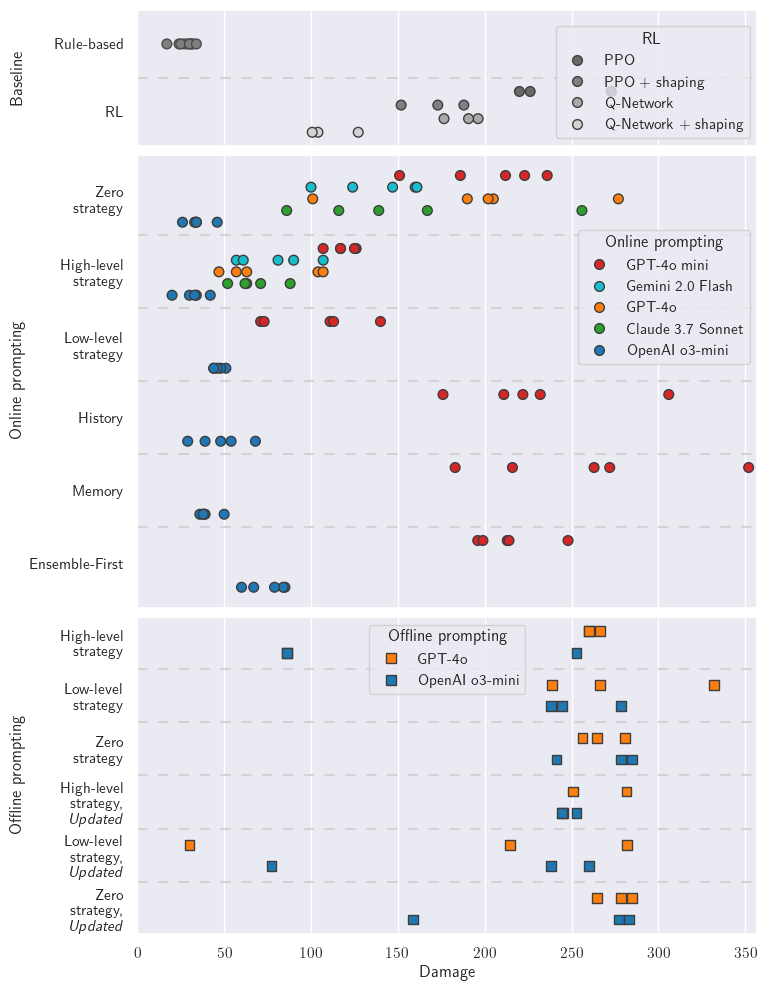

In [29]:
fig, [ax_b, ax_on, ax_off] = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(8, 12), height_ratios=[0.9, 3, 2.1])
plot_kwargs = {
    "dodge": True,
    "jitter": False,
    "size": 7,
    "linewidth": 1,
}

# Baselines
b_rule, *b_rl = baseline_names.values()
sns.stripplot(x="damage", y="params", hue="LLM", data=online[online["LLM"] == b_rule], ax=ax_b, palette={key: palette_baselines[key] for key in [b_rule]}, hue_order=[b_rule], order=rows_baselines, **plot_kwargs)
sns.stripplot(x="damage", y="params", hue="LLM", data=online[online["params"].isin(rows_baselines) & online["LLM"].isin(b_rl)], ax=ax_b, palette={key: palette_baselines[key] for key in b_rl}, hue_order=b_rl, order=rows_baselines, **plot_kwargs)

ax_b.get_legend().set_title("RL", prop={'weight': 'bold'})
sns.move_legend(ax_b, "lower right")
ax_b.set_ylabel("Baseline", weight='bold')
# add lines separating params
for y in range(0, len(rows_baselines) - 1):
    ax_b.plot([0, online['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')
ax_b.set_ylim(1.5, -0.5)

# Online
sns.stripplot(x="damage", y="params", hue="LLM", data=online[online["params"].isin(rows_llm)], ax=ax_on, palette=palette_LLM, hue_order=palette_LLM.keys(), order=rows_llm, **plot_kwargs)

ax_on.get_legend().set_title("Online prompting", prop={'weight': 'bold'})
sns.move_legend(ax_on, "upper right", bbox_to_anchor=(0, -0.15, 1, 1))
ax_on.set_ylabel("Online prompting", weight='bold')
# add lines separating params
for y in range(0, len(rows_llm) - 1):
    ax_on.plot([0, online['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')

# Offline
offline_llms = ["GPT-4o", "OpenAI o3-mini"]
sns.stripplot(x="damage", y="params", hue="LLM", data=offline_agg, ax=ax_off, palette=palette_LLM, hue_order=offline_llms, marker="s", **plot_kwargs)
ax_off.get_legend().set_title("Offline prompting", prop={'weight': 'bold'})
sns.move_legend(ax_off, "upper center")
ax_off.set_ylabel("Offline prompting", weight='bold')
# add lines separating params
for y in range(0, len(offline_agg["params"].unique()) - 1):
  ax_off.plot([0, online['damage'].max() + 5], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')


fig.subplots_adjust(wspace=0, hspace=0.03)
fig.align_ylabels([ax_b, ax_on, ax_off])
plt.xlim(0, online['damage'].max() + 5)
plt.xlabel("Damage")
plt.savefig("results/farm/farm_plot.pdf", bbox_inches="tight")
plt.show()

## Retry count plot

In [15]:
errors = pd.read_csv("results/farm/errors.csv")
errors

,llm,params,total,final,retries,filename
0,claude37sonnet,Default,0,0,0,001-2025-03-07-10-42-13-jinja_sd2_retry1_claud...
1,claude37sonnet,Default,0,0,0,002-2025-03-07-16-24-00-jinja_sd2_retry1_claud...
2,claude37sonnet,Default,0,0,0,003-2025-03-07-16-28-51-jinja_sd2_retry1_claud...
3,claude37sonnet,Default,0,0,0,004-2025-03-17-10-41-53-jinja_sd2_retry1_claud...
4,claude37sonnet,Default,0,0,0,005-2025-03-17-10-46-40-jinja_sd2_retry1_claud...
...,...,...,...,...,...,...
85,o3mini,Hinted,0,0,0,001-2025-03-07-10-13-37-jinja_sd2_retry1_o3min...
86,o3mini,Hinted,0,0,0,002-2025-03-07-15-16-08-jinja_sd2_retry1_o3min...
87,o3mini,Hinted,0,0,0,003-2025-03-07-15-31-36-jinja_sd2_retry1_o3min...
88,o3mini,Hinted,0,0,0,004-2025-03-17-09-45-46-jinja_sd2_retry1_o3min...


In [16]:
errors['LLM'] = errors['llm'].map(all_names)

C:\Users\micha\AppData\Local\Temp\ipykernel_31216\1450443891.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["params"] = data["params"].replace({"Default": "Component-First"})
C:\Users\micha\AppData\Local\Temp\ipykernel_31216\1450443891.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, "retry_percentage"] = data["retries"] / 30 * 100


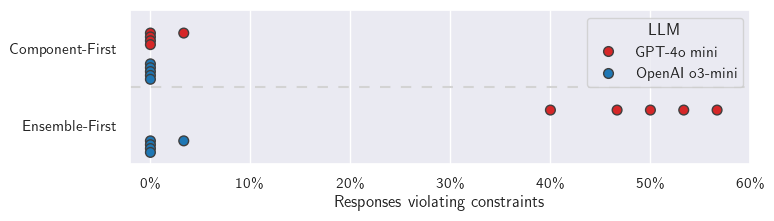

In [31]:
rows = ["Default", "Ensemble-First"]
llms = ["GPT-4o mini", "OpenAI o3-mini"]

data = errors[errors["params"].isin(rows) & errors["LLM"].isin(llms)]
data["params"] = data["params"].replace({"Default": "Component-First"})
data.loc[:, "retry_percentage"] = data["retries"] / 30 * 100

fig, ax = plt.subplots(figsize=(8, 2))
plot_kwargs_2 = {
  **plot_kwargs,
  #"jitter": 0.1,
}
sns.stripplot(x="retry_percentage", y="params", hue="LLM", data=data, ax=ax, palette={key: palette_LLM[key] for key in llms}, hue_order=llms, order=("Component-First", "Ensemble-First"), **plot_kwargs_2)

# add custom jitter
for dots in ax.collections:
    xs, ys = dots.get_offsets().T
    jitter_ys = ys[:]
    for i, x in enumerate(xs):
        count = np.sum(xs[:i] == x)
        jitter_ys[i] = ys[i] + 0.05 * count
    dots.set_offsets(np.column_stack((xs, jitter_ys)))

ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# add lines separating params
for y in range(0, len(rows) - 1):
    ax.plot([-2, 60], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')
plt.xlim(-2, 60)
plt.ylim(1.5, -0.5)

plt.xlabel("Responses violating constraints")
plt.ylabel("")
plt.savefig("results/farm/farm_errors.pdf", bbox_inches="tight")
plt.show()